**In this example, we will perform a simulation on the ligand KLN (from crystal structure 2V0M) docked to cytochrome P450 3A4 (PDB: 1W0E) using RoseTTAFold All-Atom. Subsequently, we will run the full analysis pipeline of the CYCLOPS package.**

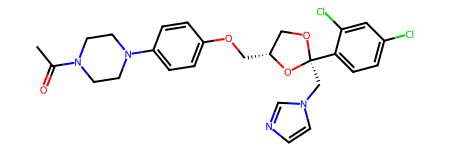

In [11]:
from rdkit import Chem
from rdkit.Chem import Draw
mol = Chem.MolFromSmiles("CC(=O)N1CCN(CC1)c2ccc(OC[C@@H]3CO[C@](Cn4ccnc4)(O3)c5ccc(Cl)cc5Cl)cc2")
mol

First, let's define some variables that will be useful in multiple places throughout this notebook.

In [1]:
#universal variables 
PDB_ID = "2V0M"
ligand_code= "KLN"
working_dir = "test_sim_dir/"

To use the original output file from the RFAA docking simulation, we need to parse it through RFAAFixer, as it contains non-standard residues.

In [2]:
from cyclops.rfaafixer import RFAAFixer
infile = "examples_structures/1W0E-2V0M-rfaa_docked.pdb"
outfile = "examples_structures/1W0E-2V0M-rfaa_fixed.pdb"
    
fixer = RFAAFixer(infile)
fixer.split_and_repair(outfile)

Gap found between residue 419 and 420 (Dist: 5.82 Å)
Gap detected after residue 419. Splitting and Repairing...
Successfully wrote: examples_structures/1W0E-2V0M-rfaa_fixed.pdb


Now, regardless of the program used, we can run the simulation in the same way.

Input PDB should contain:
- Protein residues
- Heme heavy atoms as a residue with resname HEM
- Ligand heavy atoms

Input for *run_heme_simulation* requires:
- The path for the initial strucutre 
- A name for the ligand that will be used throughout the pipeline (preferably the same as in the source crystal structure for redocking)
- Correct ligand smiles
- Path to working directory.

For other options, please refer to the documentation.

In [3]:
from cyclops.cyclops import run_heme_simulation
import os

# 1. Define your inputs
# (Using the test file as an example)
pdb_file = "examples_structures/1W0E-2V0M-rfaa_fixed.pdb"
ligand_name = ligand_code
ligand_smiles = "CC(=O)N1CCN(CC1)c2ccc(OC[C@@H]3CO[C@](Cn4ccnc4)(O3)c5ccc(Cl)cc5Cl)cc2"
output_dir = working_dir

# 2. Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 3. Run the simulation
run_heme_simulation(
    pdb_file_path=pdb_file,
    ligand_smiles=ligand_smiles,
    ligand_name=ligand_name,
    output_dir=output_dir,
    n_nanoseconds=5,  # Run for 5 ns using RTX 4070 Ti, results in ~120 ns a day. 
    verbose=True,
    write_interval_steps=100000 #extremely rare saving to be able to acoomodate the file directly on github
)


Stage 1: Preparing all input files...
Extracted residue LIG and saved as ligand.
Fixed bond orders and saved to test_sim_dir/ligand_neutral_fixed.sdf
Protonation completed. Output saved to test_sim_dir/ligand_prepared_for_sim.sdf


[13:58:10] WARNING: More than one matching pattern found - picking one



Extracted protein and saved as 'test_sim_dir/plain_protein.pdb'.
Extracted heme group without fe and saved as 'test_sim_dir/heme_without_fe_unprotonated.pdb' and extracted Fe and saved as 'test_sim_dir/Fe.pdb'.
Protonation completed. Output saved to test_sim_dir/protonated_heme_without_fe.sdf
Creating PTM protein PDB (CYS -> DYE)...
Loading protein from: test_sim_dir/fixed_plain_protein.pdb
Loading Fe atom from: test_sim_dir/Fe.pdb
Found Fe atom at coords: [18.726  8.334 68.001]
Searching for closest Cysteine (CYS) 'SG' atom to the Fe...
Found target CYS: ('protein', 0, 'A', (' ', 420, ' ')) at distance 2.25 Å
Removing 'HG' atom from CYS.
Converted CYS 420 to HETATM residue 'DYE'
Added Fe atom (named 'Fe1x') to the DYE residue.

Successfully saved new PDB to: test_sim_dir/protein_with_CYF.pdb
Running post-processing to fix Fe element formatting...
  -> Found formatting bug in line: HETATM 6812 Fe1x DYE A 420      18.726   8.334  68.001  1.00  0.00         FE
  -> Fixed line to: HETATM 

[13:58:12] WARNING: More than one matching pattern found - picking one



  Protein-PTM interchange created.
  Parameterizing Ligand...
  Parameterizing Heme (no Fe)...
...parameterization complete.
Stage 3: Assembling and solvating system...


/home/pgrenda/miniforge3/envs/cyclops-dev/lib/python3.12/site-packages/openff/interchange/operations/_combine.py:104: InterchangeCombinationWarning: Interchange object combination is complex and may produce strange results outside of use cases it has been tested in. Use with caution and thoroughly validate results!
  warnings.warn(
/home/pgrenda/miniforge3/envs/cyclops-dev/lib/python3.12/site-packages/openff/interchange/operations/_combine.py:84: InterchangeCombinationWarning: Found electrostatics 1-4 scaling factors of 5/6 with slightly different rounding (0.833333 and 0.8333333333). This likely stems from OpenFF using more digits in rounding 1/1.2. The value of 0.8333333333 will be used, which may or may not introduce small errors. 
  warnings.warn(


...assembly complete.
Stage 4: Adding custom Heme-Fe constraints (Fe-N bonds/angles)...
Modifying partial charges...
Found DYE-SG: Atom ID (Index) 6810
  - Old charge: -0.108100 e
  - New charge: -0.370100 e
Found DYE-Fe1x: Atom ID (Index) 6811
  - Old charge: +1.000000 e
  - New charge: +0.262000 e

Applying changes to the simulation context...
Charges successfully updated in the simulation.


/home/pgrenda/miniforge3/envs/cyclops-dev/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbstructure.py:204: UserWarning: Need to guess atom number  6792 starting from atom 109544.
  warnings.warn(


...custom Heme-Fe constraints added.
Stage 5: Running simulation...
  Running constrained minimization...
  Minimization complete. Unfreezing atoms.
  Heating system to 310.15 K over 100k steps...
#"Step"	"Potential Energy (kJ/mole)"	"Temperature (K)"	"Speed (ns/day)"
10000	-1136623.2420603354	1.043962349435237	0
20000	-1148722.9448323064	35.252634681634206	138
30000	-1156612.9285139441	70.03665299407842	137
40000	-1156328.1484416462	103.97941470057202	136
50000	-1151277.8890472725	138.65637997568015	134
60000	-1138757.278298661	172.01398095323862	133
70000	-1112789.871078468	207.2195245747125	132
80000	-1069977.7981370734	242.05497509874212	131
90000	-1021892.8474557837	275.7872473776257	130
100000	-973357.423223814	309.35599422788937	129
  Heating complete.
Running production for 5 ns (2500000 steps)...
110000	-973621.7862297827	309.4171831395905	129
120000	-972328.9232125953	309.77012752246065	128
130000	-971906.3646168914	312.42932401929914	128
140000	-974638.9698971119	308.8881855

Now that the simulation has finished, we can run the full analysis using the analysis module.

By default, plots are saved to the same directory where the simulation took place.

In [4]:
import cyclops.analysis

In [7]:
analyser = cyclops.analysis.HemeAnalysis(simulation_path=working_dir, 
                                         ligand_id=ligand_code,
                                         reference_pdb_path= "examples_structures/2V0M.pdb",
                                         reference_ligand_id=ligand_code,
                                         docked_pdb_path=f"{ligand_code}packed_complex.pdb", 
                                         docked_ligand_id=ligand_code,
                                         )
result = analyser.run_all_analyses()
aggregated_results = cyclops.analysis.aggregate_ligand_statistics([analyser])

aggregated_results


Loading data for test_sim_dir...


/home/pgrenda/miniforge3/envs/cyclops-dev/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbstructure.py:204: UserWarning: Need to guess atom number  6792 starting from atom 109544.
  warnings.warn(


  Loading reference: 2V0M.pdb
  Loading docked: packed_complex.pdb
Selecting atoms...
Calculating metrics...
Generating plots and saving data...
  Saved difference data to test_sim_dir_ligand_fe_diff.csv

Analysis complete for test_sim_dir


{'type': 'diff_to_ref',
 'total': {'mean': np.float32(0.28723714),
  'std': np.float32(0.12858425),
  'iqr': np.float64(0.24652393907308578),
  'q25': np.float64(0.14877746254205704),
  'q75': np.float64(0.3953014016151428),
  'count': 24},
 'part1': {'mean': np.float32(0.37877396),
  'std': np.float32(0.06686988),
  'iqr': np.float64(0.07718577980995178),
  'q25': np.float64(0.35447046160697937),
  'q75': np.float64(0.43165624141693115),
  'count': 12},
 'part2': {'mean': np.float32(0.19570035),
  'std': np.float32(0.1088038),
  'iqr': np.float64(0.06909665837883949),
  'q25': np.float64(0.13201706856489182),
  'q75': np.float64(0.2011137269437313),
  'count': 12}}

In the case of redocking studies, it is possible to analyze interactions between the ligand and protein throughout the simulation and compare them to the reference crystal structure using the CYCLOPS PLIPAnalyser module.

In [2]:
from cyclops.plipanalyser import MDPlipAnalysis
import os
import warnings
warnings.filterwarnings("ignore")

if __name__ == "__main__":
    
    # Init with VERBOSE=True
    pipeline = MDPlipAnalysis(PDB_ID, ligand_code, verbose=True, renumber_ref=False, renumber_sim=True)
    try:
        # 1. Reference
        pipeline.step1_prepare_reference()
        
        # 2. Trajectory 
        TRAJ = f"{working_dir}trajectory_complex.xtc"
        TOP = f"{working_dir}topology_complex.pdb" 
        
        if os.path.exists(TRAJ):
            # Example: Analyze every 2nd frame, but only the LAST 90% of simulation
            df = pipeline.step2_analyze_trajectory(
                TRAJ, 
                TOP, 
                stride=2, 
                analyze_fraction=0.9,
            
            )
            
            if not df.empty:
                print(df.head())
                df.to_csv(f"{working_dir}plip_md_results.csv", index=False)
                print("Done. Saved to plip_md_results.csv")
        else:
            print(f"\n[INFO] Files not found. Place '{TRAJ}' and '{TOP}' in folder to run.")
            
    finally:
        pass
        pipeline.cleanup_temporary_files()

/home/pgrenda/miniforge3/envs/cyclops-dev/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


--- Step 1: Reference (2V0M) ---
Using existing reference file: ./2V0M.pdb
Using Reference PDB as-is (Original Crystal Numbering).
Running PLIP on ./2V0M.pdb...
Reference Baseline: 4 interactions found.

--- Step 2: Trajectory Analysis ---
Topology: test_sim_dir/topology_complex.pdb
Trajectory: test_sim_dir/trajectory_complex.xtc
Recenter/Unwrap: True
Analysis Fraction 0.9: Dropping first 2 frames.
Selection Query: 'protein or resname KLN'
Selected 7916 atoms.
   [Align Check] Identity: 94.7% (480/507 residues)
   [Spot Check] MET1->1, ASP241->263, ALA481->503
   [Align Check] Identity: 94.7% (480/507 residues)
   [Spot Check] MET1->1, ASP241->263, ALA481->503
   [Align Check] Identity: 94.7% (480/507 residues)
   [Spot Check] MET1->1, ASP241->263, ALA481->503
   [Align Check] Identity: 94.7% (480/507 residues)
   [Spot Check] MET1->1, ASP241->263, ALA481->503
   [Align Check] Identity: 94.7% (480/507 residues)
   [Spot Check] MET1->1, ASP241->263, ALA481->503
   [Align Check] Identity